In [1]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration

## Load anno data

In [42]:
import sys
import os
import pandas as pd
import importlib

## Add the code directory to Python path
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    plot_confusion_matrix,
    plot_per_class_f1,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
path = '/home/lingyu/ssd2/Python/'
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCRT'
segment_data1 = 'NCRT_project - seg 1-14'
segment_data2 = 'NCRT_project - seg 15-28'
export_data = 'export'
save_result = 'result'

Successfully reloaded functions from base.py
openslide: True, tifffile: True


### Valis

In [57]:
## Load images
he_path  = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
pcf_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT PCF.qptiff'

### Alignment: Coordinates transform: PCF -> HE

- Transformation matrix exported from QuPath: [up: HE; down: PCF]
- Here, In QuPath, NCRT PCF.qptiff is the reference (front) and NCRT HE.qptiff is the target (back)
- QuPath shows HE->PCF, we need PCF->HE (INVERT the matrix)

In [ ]:
## Load images
he_path  = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
pcf_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT PCF.qptiff'

## QuPath shows HE->PCF, we need PCF->HE (INVERT the matrix)
PCF2HE_transformation_NCRT = transformation_matrix_properties(therapy_data)

## Verifying PCF -> HE alignment
# fig_verify = verify_transformation_alignment(he_path, pcf_path, PCF2HE_transformation_NCRT, 
#                                              test_regions=1, region_size=4000)

Original QuPath matrix (HE -> PCF):
[[ 9.83752773e-01 -7.72653508e-03 -5.46157726e+03]
 [ 7.72653508e-03  9.83752773e-01 -2.10318222e+03]]

Matrix properties (HE -> PCF):
  Scale: 0.9838, Rotation: 0.4427°
  Translation: X=-5461.6, Y=-2103.2

Inverted matrix (PCF -> HE):
[[ 1.01645286e+00  7.98336622e-03  5.56822628e+03]
 [-7.98336622e-03  1.01645286e+00  2.09418381e+03]]

Matrix properties (PCF -> HE):
  Scale: 1.0165, Rotation: -0.4574°
  Translation: X=5568.2, Y=2094.2


In [ ]:
## Based on pixel_size_um convert PCF coordinates to pixel coordinates
## Then use PCF2HE_transformation_NCRT to convert to HE pixel coordinates
segment_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data1}'
pixel_size_um = get_pixel_size(segment_path, segment_number='1')
celltype_pixel_NCRT_tumor1 = add_pixel_coords(celltype_NCRT_tumor1, pixel_size_um, PCF2HE_transformation_NCRT)
print("Cell numbers with NCRT tumor1:", celltype_pixel_NCRT_tumor1.shape[0])
celltype_pixel_NCRT_tumor1.head()

## Save CellPixCoords
# celltype_pixel_NCRT_tumor1.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1.csv')

pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 66240

Converting PCF_µm to PCF_pixel...
Added columns: X_pix_PCF, Y_pix_PCF
Converting PCF_pixel to HE_pixel...
Added columns: X_pix_HE, Y_pix_HE
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm', 'X_pix_PCF', 'Y_pix_PCF', 'X_pix_HE', 'Y_pix_HE']
Cell numbers with NCRT tumor1: 82805


,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462


In [ ]:
## celltype_NCRT
celltype_NCRT = get_celltype_coords(celltype_anno_df, celltype_coords_df, value='NCRT', parent_value=None)
# celltype_NCRT.head()
celltype_pixel_NCRT = add_pixel_coords(celltype_NCRT, pixel_size_um, PCF2HE_transformation_NCRT)
print("Cell numbers with NCRT:", celltype_pixel_NCRT.shape[0])
print(celltype_pixel_NCRT.shape)
celltype_pixel_NCRT.head()

## Save CellPixCoords
# celltype_pixel_NCRT.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords.csv')

['Unnamed: 0', 'CellID', 'TumorID', 'celltype']
Dont filtering - parent value: 'Parent' column
Available columns: ['Image', 'CellID', 'Name', 'Class', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Detection probability', 'Nucleus: Area µm^2']
Shape of celltype_NCRT_tumor1 after merging: (1892408, 6)

Columns after merging: ['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm']
Successfully matched cells: 1892408 / 1892408 (100.00%)

Converting PCF_µm to PCF_pixel...
Added columns: X_pix_PCF, Y_pix_PCF
Converting PCF_pixel to HE_pixel...
Added columns: X_pix_HE, Y_pix_HE
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm', 'X_pix_PCF', 'Y_pix_PCF', 'X_pix_HE', 'Y_pix_HE']
Cell numbers with NCRT: 1892408
(1892408, 10)


,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462


## HIPT

<!-- ## Option A: Using HIPT (recommended for quick start, no token required)
python ./demo/Image_feature_extraction.py \
   --dataset NPC \
   --position_path FineST_tutorial_data/spatial/tissue_positions_list.csv \
   --rawimage_path FineST_tutorial_data/20210809-C-AH4199551.tif \
   --scale_image False \
   --method HIPT \
   --patch_size 64 \
   --output_img FineST_tutorial_data/ImgEmbeddings/pth_64_16_image \
   --output_pth FineST_tutorial_data/ImgEmbeddings/pth_64_16 \
   --logging FineST_tutorial_data/ImgEmbeddings/Logging/ \
   --scale 0.5  # default is 0.5 -->

In [ ]:
## Load celltype_pixel_NCRT
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords.csv')
celltype_pixel_NCRT.head()

,Unnamed: 0.1,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE
0,0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13897.215308,2051.062848
1,1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13520.274149,2057.162996
2,2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13634.263435,2056.222826
3,3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13923.441794,2054.545470
4,4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13572.482218,2058.390326


In [ ]:
celltype_pixel_NCRT.rename(columns={'X_pix_HE': 'pxl_row_in_fullres', 'Y_pix_HE': 'pxl_col_in_fullres'}, inplace=True)
celltype_pixel_NCRT.head()
## save celltype_pixel_NCRT for HIPT
# celltype_pixel_NCRT.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_HIPT.csv')

,Unnamed: 0.1,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,pxl_row_in_fullres,pxl_col_in_fullres
0,0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13897.215308,2051.062848
1,1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13520.274149,2057.162996
2,2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13634.263435,2056.222826
3,3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13923.441794,2054.545470
4,4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13572.482218,2058.390326


In [ ]:
# ## Load celltype_pixel_NCRT
# path = '/home/lingyu/ssd2/Python/'
# therapy_data = 'NCRT'
# celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1.csv')
# # celltype_pixel_NCRT.head()
# celltype_pixel_NCRT.rename(columns={'X_pix_HE': 'pxl_row_in_fullres', 'Y_pix_HE': 'pxl_col_in_fullres'}, inplace=True)
# # celltype_pixel_NCRT.head()
# celltype_pixel_NCRT.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1_HIPT.csv')

In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/data/Python/Collaborate/esccAI/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords_tumor1_HIPT.csv \
#    --rawimage_path data/NCRT/NCRT_HE.qptiff \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/ImgEmbeddings_tumor1/sc_pth_16_16_image \
#    --output_pth data/NCRT/ImgEmbeddings_tumor1/sc_pth_16_16 \
#    --logging data/NCRT/ImgEmbeddings_tumor1/ \
#    --scale 0.5  

## Cell Type Classification Model

In [ ]:
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
segment_data1 = 'NCRT_project - seg 1-14'
export_data = 'export'

In [ ]:
# Load required libraries for machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                            precision_score, recall_score, f1_score, 
                            precision_recall_fscore_support)
import seaborn as sns
import torch
from pathlib import Path
from tqdm import tqdm
import re
import os
import numpy as np
import pandas as pd

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# Load celltype data (ground truth Y)
# Use celltype_pixel_NCRT_tumor1 which has X_pix_HE and Y_pix_HE coordinates
print("Loading celltype data...")

# Check if celltype_pixel_NCRT_tumor1 exists, if not, create it
if 'celltype_pixel_NCRT_tumor1' not in globals():
    print("  celltype_pixel_NCRT_tumor1 not found, loading from file or creating...")
    # Try to load from CSV if exists
    tumor1_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1.csv'
    import os
    if os.path.exists(tumor1_coords_path):
        celltype_pixel_NCRT_tumor1 = pd.read_csv(tumor1_coords_path)
        print(f"  Loaded from {tumor1_coords_path}")
    else:
        # Create it from celltype_NCRT_tumor1 if available
        if 'celltype_NCRT_tumor1' in globals():
            print("  Creating celltype_pixel_NCRT_tumor1 from celltype_NCRT_tumor1...")
            celltype_pixel_NCRT_tumor1 = add_pixel_coords(celltype_NCRT_tumor1, pixel_size_um, PCF2HE_transformation_NCRT)
        else:
            raise ValueError("celltype_NCRT_tumor1 not found. Please run Cell 20 first.")

print(f"  Loaded {len(celltype_pixel_NCRT_tumor1)} cells")
print(f"  Columns: {celltype_pixel_NCRT_tumor1.columns.tolist()}")
print(f"  Cell types: {celltype_pixel_NCRT_tumor1['celltype'].nunique()} unique types")
print(f"  Cell type distribution:\n{celltype_pixel_NCRT_tumor1['celltype'].value_counts()}")

Loading celltype data...
  celltype_pixel_NCRT_tumor1 not found, loading from file or creating...


  Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/he_cell_coords/NCRT_CellPixCoords_tumor1.csv
  Loaded 82805 cells
  Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'Centroid X µm', 'Centroid Y µm', 'X_pix_PCF', 'Y_pix_PCF', 'X_pix_HE', 'Y_pix_HE']
  Cell types: 42 unique types
  Cell type distribution:
celltype
Epithelial               16508
Muscle&mCAF               7372
Plasma                    6308
CD8_Tpex                  5978
Monocyte                  4767
Treg                      4520
CAF_other                 4181
Tumor_PDL1pos_MHCIpos     3801
Tumor_PDL1neg_MHCIpos     3526
Macro_other               3355
Neutrophil                3075
Endothelial               2881
CD4_Tex                   2502
Low_quality               2476
CD8_Tex                   2310
Tumor_PDL1neg_MHCIneg     2263
Macro_M1                  1023
DC_mature                  747
pDC                        738
CD8_Teff                   723
CD8_Trm_ex                 

In [ ]:
# Load HIPT embeddings from .pth files (Input X)
print("Loading HIPT embeddings from .pth files...")

embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/ImgEmbeddings_tumor1/sc_pth_16_16')
pth_files = list(embedding_dir.glob('*.pth'))
print(f"  Found {len(pth_files)} .pth files")

embeddings_dict, failed_files = load_embeddings(pth_files)

print(f"  Successfully loaded {len(embeddings_dict)} embeddings")
if len(failed_files) > 5:
    print(f"  ... and {len(failed_files) - 5} more files failed to load")
if len(failed_files) > 0:
    print(f"  Total failed: {len(failed_files)} files")

if len(embeddings_dict) > 0:
    sample_emb = list(embeddings_dict.values())[0]
    print(f"  Embedding dimension: {sample_emb.shape}")
    print(f"  Sample embedding dtype: {sample_emb.dtype}")
else:
    print("  ERROR: No embeddings loaded! Please check the .pth files.")

Loading HIPT embeddings from .pth files...
  Found 82805 .pth files
  Loading embeddings...


Loading .pth files: 100%|██████████| 82805/82805 [00:24<00:00, 3403.16it/s]

  Successfully loaded 82805 embeddings
  Embedding dimension: (384,)
  Sample embedding dtype: float32


In [ ]:
# Match embeddings with celltype data by coordinates
# Check if matched data already exists
# os.remove(matched_features_path)    # remove matched_features_tumor1.npz

import pickle
matched_data_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/matched_data_tumor1.pkl'
matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/matched_features_tumor1.npz'
# Load matched embeddings (returns X, y, and optionally X_coords)
result = prepare_matched_embeddings(celltype_pixel_NCRT_tumor1, embeddings_dict, matched_features_path, coord_cols=('X_pix_HE', 'Y_pix_HE'))
if len(result) == 3:
    X, y, X_coords_matched = result
    if X_coords_matched is not None:
        print(f"  ✓ Coordinates loaded: {X_coords_matched.shape}")
else:
    X, y = result
    X_coords_matched = None
    print(f"  ⚠ Coordinates not available (old format)")

Loading pre-saved matched data...


  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/matched_features_tumor1.npz
  X shape: (82805, 384)
  y shape: (82805,)
  Number of classes: 42
  Classes: ['B_other', 'B_proliferating', 'Bm_switched', 'Bm_unswitched', 'Bn', 'CAF_ap', 'CAF_other', 'CD4_Tcm', 'CD4_Tem', 'CD4_Tex', 'CD4_Tn', 'CD8_Teff', 'CD8_Tem', 'CD8_Tex', 'CD8_Tn', 'CD8_Tpex', 'CD8_Trm', 'CD8_Trm_ex', 'DC_mature', 'Endothelial', 'Epithelial', 'HEV', 'Low_quality', 'Macro_M1', 'Macro_other', 'Monocyte', 'Muscle&mCAF', 'Neutrophil', 'Plasma', 'Tfh_CXCL13', 'Tfh_CXCL13_CXCR5', 'Tfh_CXCR5', 'Th17', 'Treg', 'Tumor_PDL1neg_MHCIneg', 'Tumor_PDL1neg_MHCIpos', 'Tumor_PDL1pos_MHCIneg', 'Tumor_PDL1pos_MHCIpos', 'cDC1', 'cDC2', 'non_specific', 'pDC']
  ⚠ Coordinates not found in saved data (old format)


In [ ]:
# Filter out 'Low_quality' and 'non_specific' cells
print("Filtering out 'Low_quality' and 'non_specific' cells...")

# Define cells to exclude
exclude_labels = ['Low_quality', 'non_specific']

# Create mask for cells to keep
keep_mask = ~np.isin(y, exclude_labels)

# Count cells before and after filtering
n_before = len(y)
n_after = keep_mask.sum()
n_filtered = n_before - n_after

print(f"  Before filtering: {n_before:,} cells")
print(f"  Filtering out: {n_filtered:,} cells")
for label in exclude_labels:
    count = np.sum(y == label)
    if count > 0:
        print(f"    - {label}: {count:,} cells")

# Apply filter
X_filter = X[keep_mask]
y_filter = y[keep_mask]

print(f"  After filtering: {n_after:,} cells")
print(f"  X_filter shape: {X_filter.shape}")
print(f"  y_filter shape: {y_filter.shape}")
print(f"  Remaining classes: {len(np.unique(y_filter))}")

# Update X and y for subsequent use
X = X_filter
y = y_filter

print(f"\n  ✓ Filtered data ready (X, y updated)")

Filtering out 'Low_quality' and 'non_specific' cells...
  Before filtering: 82,805 cells
  Filtering out: 2,502 cells
    - Low_quality: 2,476 cells
    - non_specific: 26 cells
  After filtering: 80,303 cells
  X_filter shape: (80303, 384)
  y_filter shape: (80303,)
  Remaining classes: 40

  ✓ Filtered data ready (X, y updated)


Preparing data for modeling...
  Created backup of original data (X_original, y_original)
  Encoded 40 cell types

  Class distribution (sorted by count):
Epithelial               16508
Muscle&mCAF               7372
Plasma                    6308
CD8_Tpex                  5978
Monocyte                  4767
Treg                      4520
CAF_other                 4181
Tumor_PDL1pos_MHCIpos     3801
Tumor_PDL1neg_MHCIpos     3526
Macro_other               3355
Neutrophil                3075
Endothelial               2881
CD4_Tex                   2502
CD8_Tex                   2310
Tumor_PDL1neg_MHCIneg     2263
Macro_M1                  1023
DC_mature                  747
pDC                        738
CD8_Teff                   723
CD8_Trm_ex                 444
B_other                    426
Bm_switched                376
Bm_unswitched              354
cDC2                       294
CD4_Tem                    274
CAF_ap                     223
cDC1                       219
Th17    

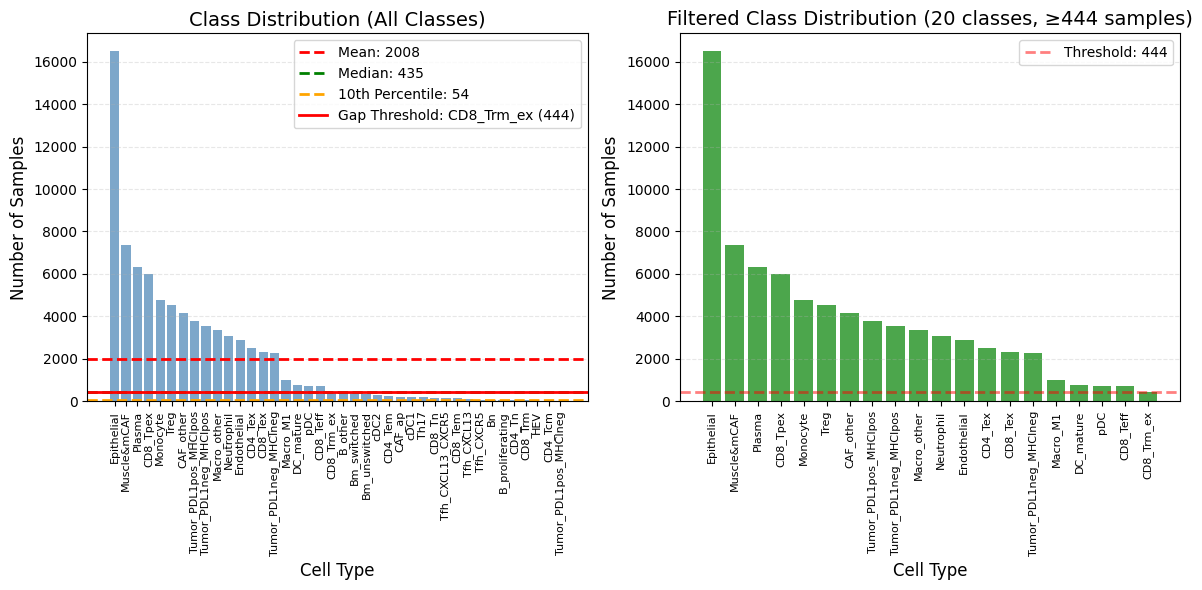


  Filtering results:
    Classes to keep: 20
    Classes to filter out: 20
    Filtered classes (< 444 samples):
      - B_other: 426 samples
      - Bm_switched: 376 samples
      - Bm_unswitched: 354 samples
      - cDC2: 294 samples
      - CD4_Tem: 274 samples
      - CAF_ap: 223 samples
      - cDC1: 219 samples
      - Th17: 200 samples
      - CD8_Tn: 165 samples
      - Tfh_CXCL13_CXCR5: 148 samples
      - CD8_Tem: 143 samples
      - Tfh_CXCL13: 115 samples
      - Tfh_CXCR5: 69 samples
      - Bn: 69 samples
      - B_proliferating: 59 samples
      - CD4_Tn: 54 samples
      - CD8_Trm: 52 samples
      - HEV: 35 samples
      - CD4_Tcm: 5 samples
      - Tumor_PDL1pos_MHCIneg: 1 samples

  Applying filtering (removing classes with < 444 samples)...
  Before filtering: 80,303 samples, 40 classes
  After filtering: 77,022 samples, 20 classes
  Remaining class statistics:
    Max: 16,508 (Epithelial)
    Min: 444 (CD8_Trm_ex)
    Median: 3215.0
    Mean: 3851.1
    New imbala

In [ ]:
# Encode labels and prepare data with automatic gap-based filtering
print("Preparing data for modeling...")

# Check if X and y are defined (from previous cell)
if 'X' not in globals() or 'y' not in globals():
    raise NameError(
        "Variables 'X' and 'y' are not defined. Please run the previous cell "
        "(Cell 49: Match embeddings with celltype data) first to load or create the matched data."
    )

# Create copies to avoid modifying original data (allows re-running this cell)
# If original data backup exists, restore from backup; otherwise create backup
if 'X_original' not in globals() or 'y_original' not in globals():
    # First time running: create backup of original data
    X_original = X.copy() if hasattr(X, 'copy') else np.array(X)
    y_original = y.copy() if hasattr(y, 'copy') else np.array(y)
    print("  Created backup of original data (X_original, y_original)")
else:
    # Restore from backup if re-running
    print("  Restoring from backup (X_original, y_original)")
    X = X_original.copy() if hasattr(X_original, 'copy') else np.array(X_original)
    y = y_original.copy() if hasattr(y_original, 'copy') else np.array(y_original)

# Call the function to analyze and filter classes
result = analyze_and_filter_classes_by_gap(X, y, ratio_threshold=1.5, abs_diff_threshold=100)

# Extract results
X = result['X_filtered']
y = result['y_filtered']
y_encoded = result['y_encoded']
class_names = result['class_names']
threshold_cell_type = result['threshold_cell_type']
threshold_count = result['threshold_count']
min_samples_per_class = result['min_samples_per_class']


### Train and test datasets 

In [ ]:
# Train/Test split (70% / 30%)
X_train, X_test, y_train, y_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y, y_encoded, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_encoded  # Ensure balanced class distribution
)

print(f"\nTrain/Test split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Feature dimension: {X_train.shape[1]}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"  Features standardized")


Train/Test split:
  Training set: 53502 samples
  Test set: 22930 samples
  Feature dimension: 384
  Features standardized


## MLP classifier

In [ ]:
# Check GPU availability
import torch
import torch.nn as nn

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Warning: CUDA not available, will use CPU (slower)")

CUDA available: False


In [ ]:
## Create PyTorch Dataset and DataLoader
train_dataset, val_dataset, train_loader, val_loader = create_dataloaders(
    X_train_scaled, y_train_encoded, X_test_scaled, y_test_encoded
)

NameError: name 'X_train_scaled' is not defined

In [ ]:
# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train_encoded))  # Use actual number of classes in training data

print(f"Model configuration:")
print(f"  Input dimension: {input_dim}")
print(f"  Number of classes: {num_classes}")
print(f"  Class names: {class_names}")

# Use improved model with larger capacity
model = ImprovedMLPClassifier(
    input_dim=input_dim, 
    num_classes=num_classes,  # Use actual number of classes
    hidden_dims=[1024, 512, 256],  # Larger capacity
    dropout=0.2  # Reduced dropout
).to(device)

print(f"Model initialized on {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Calculate class weights for imbalanced data
# Use only classes that appear in training data
unique_classes = np.unique(y_train_encoded)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=unique_classes,
    y=y_train_encoded
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Class weights computed for {len(unique_classes)} classes")
print(f"  Weight range: min={class_weights.min():.3f}, max={class_weights.max():.3f}")
print(f"  Weight tensor shape: {class_weights_tensor.shape}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer with better learning rate
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,  # Higher initial learning rate
    weight_decay=5e-5,  # Reduced weight decay
    betas=(0.9, 0.999),
    eps=1e-8
)

# Learning rate scheduler with warmup
from torch.optim.lr_scheduler import OneCycleLR

scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=50,  # More epochs
    steps_per_epoch=len(train_loader),
    pct_start=0.1,  # 10% warmup
    anneal_strategy='cos'
)

# Mixed precision training (AMP)
# Note: Using 'amp_scaler' to avoid conflict with 'scaler' (StandardScaler) from Cell 52
amp_scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
print(f"Mixed precision training: {amp_scaler is not None}")
print(f"Using OneCycleLR scheduler with warmup")

NameError: name 'torch' is not defined

In [ ]:
## Train 
best_weighted_f1, best_macro_f1, best_epoch = train_model(
    model, train_loader, val_loader, optimizer, scheduler, criterion,
    evaluate, device, amp_scaler, path, therapy_data, patience=10, max_epochs=50
)

Starting training with improved model...



Epoch 1/50 (5.24s, LR: 0.000132)
  Train Loss: 5.1652
  Val Accuracy: 0.2292
  Val Macro-F1: 0.1187
  Val Weighted-F1: 0.2415
  ✓ Best model saved (Weighted-F1: 0.2415, Macro-F1: 0.1187)

Epoch 2/50 (4.82s, LR: 0.000372)
  Train Loss: 3.4622
  Val Accuracy: 0.2530
  Val Macro-F1: 0.1296
  Val Weighted-F1: 0.2580
  ✓ Best model saved (Weighted-F1: 0.2580, Macro-F1: 0.1296)

Epoch 3/50 (4.89s, LR: 0.000669)
  Train Loss: 2.8469
  Val Accuracy: 0.2700
  Val Macro-F1: 0.1251
  Val Weighted-F1: 0.2654
  ✓ Best model saved (Weighted-F1: 0.2654, Macro-F1: 0.1251)

Epoch 4/50 (4.95s, LR: 0.000909)
  Train Loss: 2.7058
  Val Accuracy: 0.2684
  Val Macro-F1: 0.1347
  Val Weighted-F1: 0.2684
  ✓ Best model saved (Weighted-F1: 0.2684, Macro-F1: 0.1347)

Epoch 5/50 (4.85s, LR: 0.001000)
  Train Loss: 2.6361
  Val Accuracy: 0.2810
  Val Macro-F1: 0.1430
  Val Weighted-F1: 0.2819
  ✓ Best model saved (Weighted-F1: 0.2819, Macro-F1: 0.1430)

Epoch 6/50 (4.68s, LR: 0.000999)
  Train Loss: 2.5857
  Val

In [ ]:
# Load best model and evaluate on test set
print("Loading best model and evaluating on test set...")

model.load_state_dict(torch.load(f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/best_mlp_gpu.pt"))
test_acc, test_macro_f1, test_weighted_f1, test_preds, test_labels = evaluate(model, val_loader, device)

print(f"\nFinal Test Set Performance:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Macro F1-score: {test_macro_f1:.4f}")
print(f"  Weighted F1-score: {test_weighted_f1:.4f}")

# Get actual class labels that appear in the test set
unique_labels = np.unique(np.concatenate([test_labels, test_preds]))
actual_class_names = [class_names[i] for i in unique_labels]

# Detailed classification report (only for classes that appear in test set)
print(f"\nDetailed Classification Report:")
print(f"  Number of classes in test set: {len(unique_labels)}")
print(classification_report(test_labels, test_preds, labels=unique_labels, target_names=actual_class_names, zero_division=0))

Loading best model and evaluating on test set...

Final Test Set Performance:
  Accuracy: 0.3313
  Macro F1-score: 0.1895
  Weighted F1-score: 0.3304

Detailed Classification Report:
  Number of classes in test set: 20
                       precision    recall  f1-score   support

            CAF_other       0.17      0.14      0.15      1254
              CD4_Tex       0.08      0.10      0.09       751
             CD8_Teff       0.05      0.17      0.07       217
              CD8_Tex       0.07      0.10      0.08       693
             CD8_Tpex       0.16      0.07      0.09      1793
           CD8_Trm_ex       0.01      0.02      0.02       133
            DC_mature       0.03      0.08      0.05       224
          Endothelial       0.15      0.22      0.18       864
           Epithelial       0.79      0.80      0.80      4953
             Macro_M1       0.04      0.08      0.05       307
          Macro_other       0.10      0.12      0.11      1007
             Monocyte   

Computing confusion matrix...


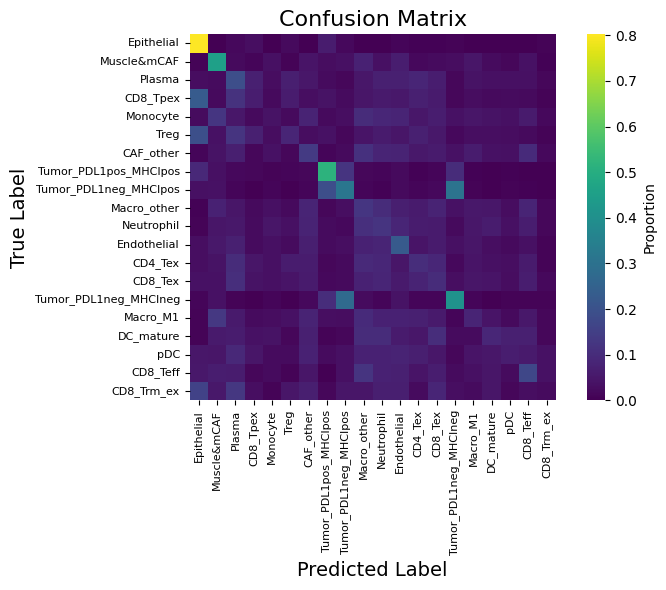

In [ ]:
plot_confusion_matrix(test_labels, test_preds, class_names, normalize=True,
    # save_path="confusion_matrix_main.pdf"
)

Visualizing per-class performance...
  ✓ Computed metrics for 20 classes


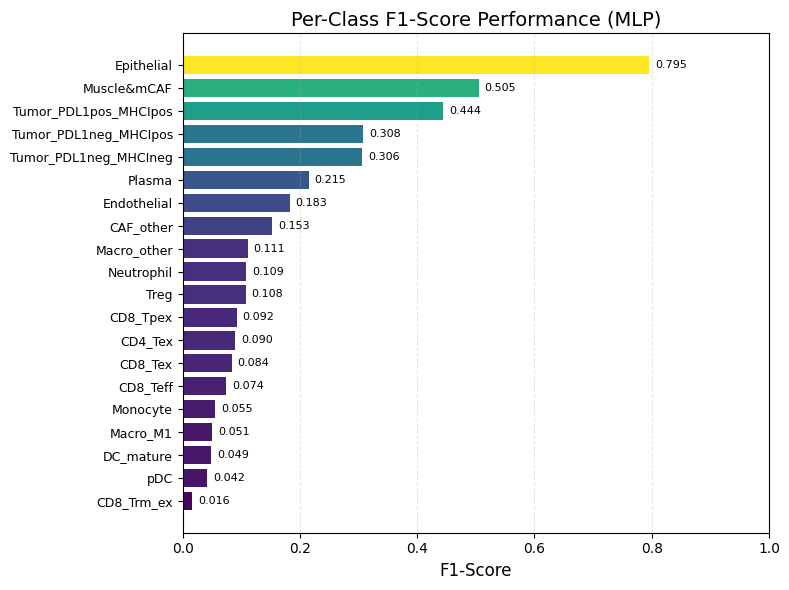


Model Summary:
  Device: cpu
  Training samples: 53915
  Test samples: 23107
  Total classes (before filtering): 20
  Actual classes in test set: 20
  Feature dimension: 384
  Model parameters: 1,059,092
  Best epoch: 47
  Test Accuracy: 0.3313
  Test Macro F1: 0.1895
  Test Weighted F1: 0.3304


In [ ]:
metrics_df = plot_per_class_f1(
    test_labels,
    test_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=test_acc,
    test_macro_f1=test_macro_f1,
    test_weighted_f1=test_weighted_f1,
    model_name="MLP",
    # save_path="per_class_f1.pdf"
)


Loading best model and evaluating on all data (in original order)...
  Using original filtered X and y...


  Total samples: 77022

Final Performance on All Data:
  Accuracy: 0.4687
  Macro F1-score: 0.3882
  Weighted F1-score: 0.4588

Detailed Classification Report:
  Number of classes: 20
                       precision    recall  f1-score   support

            CAF_other       0.28      0.20      0.23      4181
              CD4_Tex       0.29      0.38      0.33      2502
             CD8_Teff       0.19      0.71      0.30       723
              CD8_Tex       0.26      0.39      0.32      2310
             CD8_Tpex       0.35      0.14      0.20      5978
           CD8_Trm_ex       0.37      0.69      0.48       444
            DC_mature       0.25      0.66      0.37       747
          Endothelial       0.33      0.48      0.39      2881
           Epithelial       0.82      0.82      0.82     16508
             Macro_M1       0.26      0.62      0.37      1023
          Macro_other       0.23      0.28      0.25      3355
             Monocyte       0.36      0.13      0.19      4

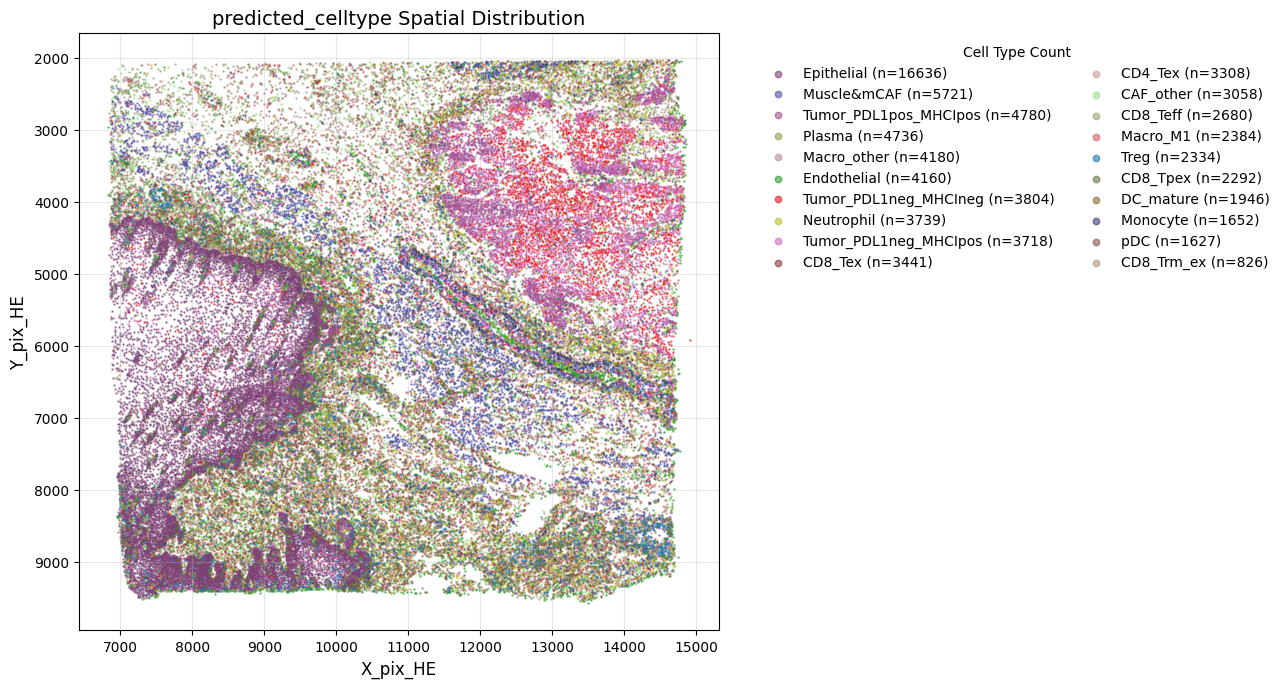


Plotting spatial distribution of TRUE cell types (for comparison)...


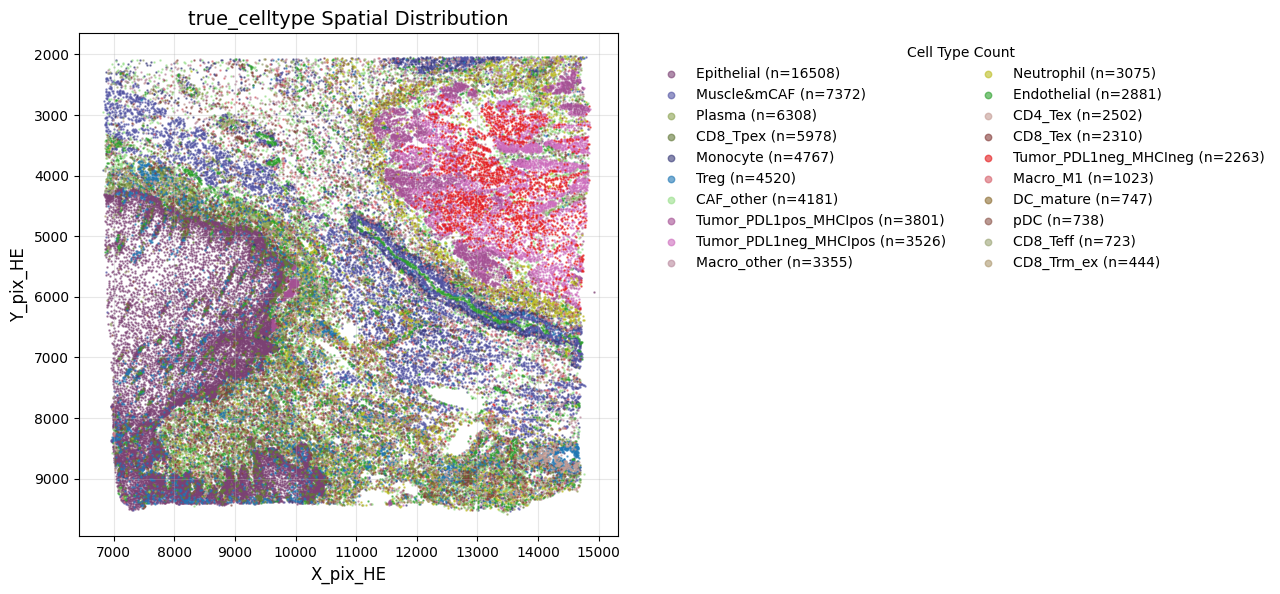

In [ ]:
# Load best model and prepare paths
print("Loading best model and evaluating on all data (in original order)...")
model.load_state_dict(torch.load(f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/best_mlp_gpu.pt"))
matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/matched_features_tumor1.npz'

# Evaluate on all data and plot spatial distribution
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path=matched_features_path,
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=val_loader if 'val_loader' in globals() else None,
    X=X if 'X' in globals() else None,
    y=y if 'y' in globals() else None,
    y_encoded=y_encoded if 'y_encoded' in globals() else None,
    X_train=X_train if 'X_train' in globals() else None,
    X_train_scaled=X_train_scaled if 'X_train_scaled' in globals() else None,
    X_test_scaled=X_test_scaled if 'X_test_scaled' in globals() else None,
    y_train_encoded=y_train_encoded if 'y_train_encoded' in globals() else None,
    y_test_encoded=y_test_encoded if 'y_test_encoded' in globals() else None,
    min_samples_per_class=min_samples_per_class if 'min_samples_per_class' in globals() else 29,
    X_coords_matched=X_coords_matched if 'X_coords_matched' in globals() else None,
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if 'celltype_pixel_NCRT_tumor1' in globals() else None
)

## HE-feature validation

```python
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
segment_data1 = 'NCRT_project - seg 1-14'
export_data = 'export'
```

In [ ]:
## Load stardist coords from YuLu - no duplicates
# star_coords = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data1}/tumor6_prob0.01_nms_0.3.csv')
star_coords = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data1}/tumor6_prob0.01_nms_0.3float.csv')
print(star_coords.shape)
star_coords.head() 

(2028114, 3)


,centroid_x,centroid_y,probability
0,2310.191299,53.845082,0.654038
1,6863.988266,3320.483284,0.884281
2,7168.098045,1736.226154,0.878382
3,7189.928642,1536.107811,0.877665
4,7227.680878,1686.196735,0.875756


In [ ]:
## filter ROI using ROI coords from Qupath annotation by myself
roi_coords = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data1}/ROI_Corners.csv')
print(roi_coords.shape)
roi_coords.head()

(28, 9)


,Name,TopLeft_X,TopLeft_Y,TopRight_X,TopRight_Y,BottomRight_X,BottomRight_Y,BottomLeft_X,BottomLeft_Y
0,tumor27,24361.0,58935.0,32781.0,58935.0,32781.0,67524.0,24361.0,67524.0
1,tumor10,15298.0,20327.0,23887.0,20327.0,23887.0,29136.0,15298.0,29136.0
2,tumor24,33103.0,49617.0,41793.0,49617.0,41793.0,58037.0,33103.0,58037.0
3,tumor22,15654.0,49719.0,24209.0,49719.0,24209.0,58122.0,15654.0,58122.0
4,tumor4,33018.0,1184.0,41607.0,1184.0,41607.0,9586.0,33018.0,9586.0


In [ ]:
## Match StarCoords to ROI
star_coords_out, star_coords_in_roi, roi_cell_counts = match_StarCoords2ROI(
    star_coords, roi_coords, therapy_data="NCRT"
)

Number of rows with TumorID = NaN: 2676
star_coords shape after filtering: (2025438, 4)
       TumorID   centroid_x   centroid_y  probability
0  NCRT_tumor1  6863.988266  3320.483284     0.884281
1  NCRT_tumor1  7168.098045  1736.226154     0.878382
2  NCRT_tumor1  7189.928642  1536.107811     0.877665
3  NCRT_tumor1  7227.680878  1686.196735     0.875756
4  NCRT_tumor1  7272.088211  2399.935646     0.872943
Nuclei number within each ROI (sorted by TumorID):
         TumorID  cell_count
2    NCRT_tumor1       94963
4    NCRT_tumor2       91422
26   NCRT_tumor3       43568
18   NCRT_tumor4       65337
5    NCRT_tumor5       86115
23   NCRT_tumor6       58079
27   NCRT_tumor7       25843
25   NCRT_tumor8       53104
10   NCRT_tumor9       77542
24  NCRT_tumor10       57359
8   NCRT_tumor11       79697
9   NCRT_tumor12       79563
14  NCRT_tumor13       72766
11  NCRT_tumor14       74430
21  NCRT_tumor15       60176
20  NCRT_tumor16       61779
7   NCRT_tumor17       84053
3   NCRT_tumor1

In [ ]:
## Load GT and CellPixCoords
celltype_anno_df = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype.csv')
celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords.csv')

ROIs where orange bar (HE: cell_count) is lower than blue bar (PCF: celltype_count):
['NCRT_tumor3', 'NCRT_tumor6', 'NCRT_tumor10', 'NCRT_tumor15', 'NCRT_tumor25', 'NCRT_tumor28']


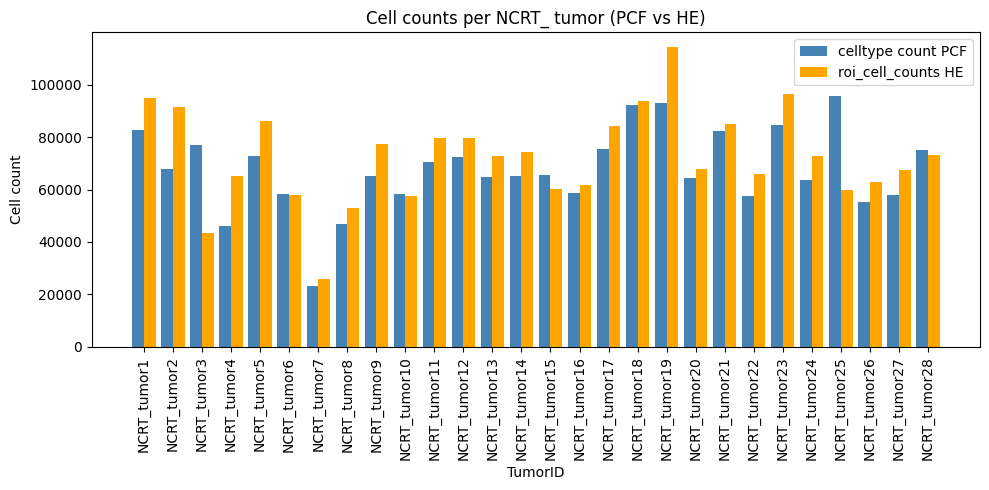

,TumorID,celltype_count,cell_count,tumor_num
0,NCRT_tumor1,82805,94963,1
1,NCRT_tumor2,67990,91422,2
2,NCRT_tumor3,77130,43568,3
3,NCRT_tumor4,46044,65337,4
4,NCRT_tumor5,72694,86115,5


In [ ]:
merged = plot_WSI_counts(celltype, roi_cell_counts, prefix='NCRT_')
merged.head()

NCRT_tumor3 - star_coords_in_roi shape: (43568, 4)
NCRT_tumor3 - celltype_pixel_NCRT shape: (77130, 11)


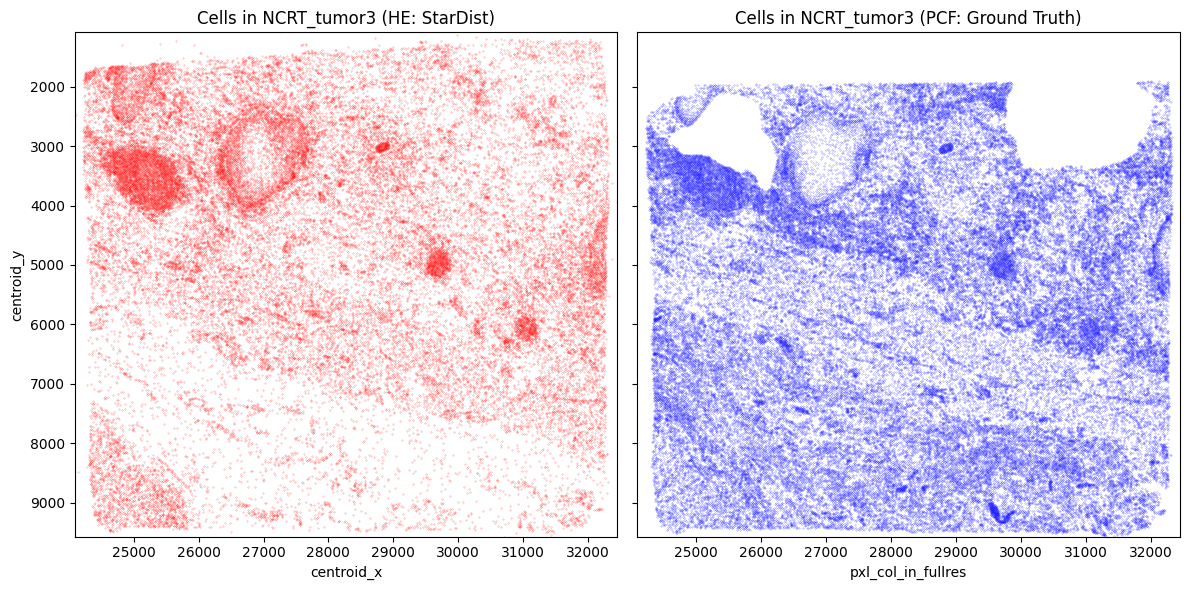

In [ ]:
plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI='NCRT_tumor3')

NCRT_tumor1 - star_coords_in_roi shape: (94963, 4)
NCRT_tumor1 - celltype_pixel_NCRT shape: (82805, 12)


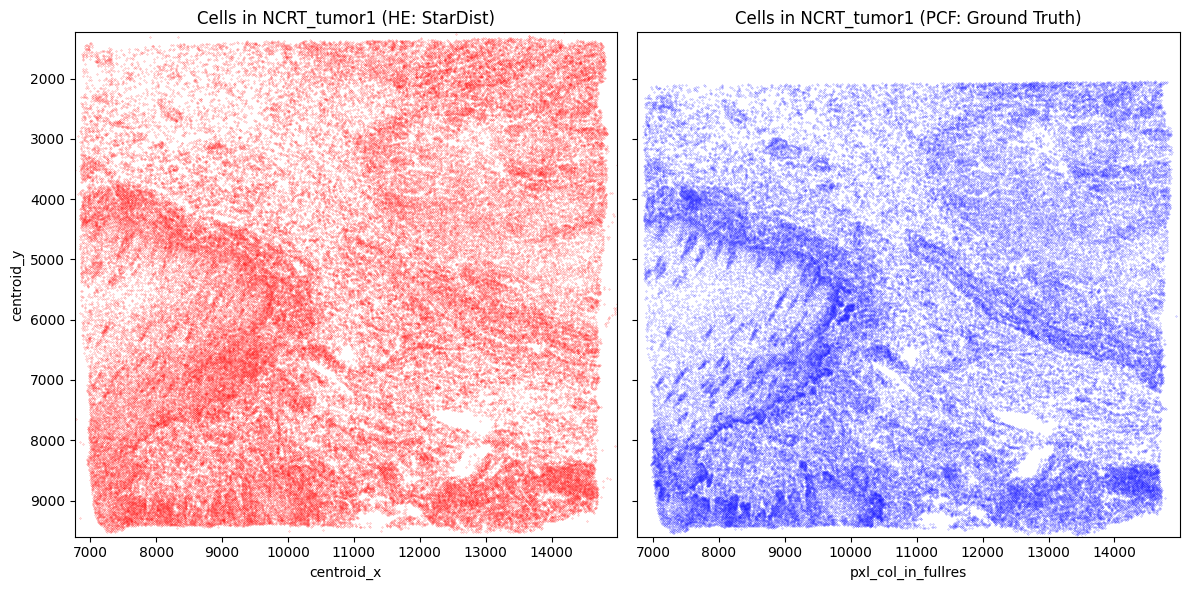

In [ ]:
plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI='NCRT_tumor1')

In [ ]:
## Load celltype_pixel_NCRT and StarDist in Tumor1
celltype_pixel_NCRT_tumor1 = celltype_pixel_NCRT[celltype_pixel_NCRT['TumorID']=='NCRT_tumor1']
celltype_pixel_NCRT_tumor1.head()

,Unnamed: 0.1,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE
0,0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13897.215308,2051.062848
1,1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13520.274149,2057.162996
2,2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13634.263435,2056.222826
3,3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13923.441794,2054.545470
4,4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13572.482218,2058.390326


In [ ]:
star_coords_in_roi1 = star_coords_in_roi[star_coords_in_roi['TumorID']=='NCRT_tumor1']
star_coords_in_roi1.head()

,TumorID,centroid_x,centroid_y,probability
0,NCRT_tumor1,6863.988266,3320.483284,0.884281
1,NCRT_tumor1,7168.098045,1736.226154,0.878382
2,NCRT_tumor1,7189.928642,1536.107811,0.877665
3,NCRT_tumor1,7227.680878,1686.196735,0.875756
4,NCRT_tumor1,7272.088211,2399.935646,0.872943


In [ ]:
celltype_pixel_NCRT_stardist = match_celltype2stardist(
    celltype_pixel_NCRT_tumor1, 
    star_coords_in_roi1, 
    celltype_pixel_coords_cols=['X_pix_HE', 'Y_pix_HE'], 
    stardist_pixel_coords_cols=['centroid_x', 'centroid_y']
)
print(celltype_pixel_NCRT_stardist.shape)
celltype_pixel_NCRT_stardist.head()

celltype_pixel_coords shape: (82805, 2)
stardist_pixel_coords shape: (94963, 2)
Building KDTree for star_coords...
Finding 100 nearest neighbors for each celltype point...


Nearest neighbor search completed. Distance matrix shape: (82805, 100)

Using greedy nearest neighbor matching...
Matched 79605 points
Matched distance: Mean, Median, Max: 18.87, 10.41, 296.24

Matched points summary:
  Total points in celltype_pixel_coords: 82805
  Matched points: 79605
  Unmatched points: 3200
Matched of PCF-HE-StarDist: (79605, 14)
(79605, 14)


,Unnamed: 0.1,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE,centroid_x,centroid_y,matched_distance
0,0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13897.215308,2051.062848,13900.070045,2063.837814,13.090046
1,1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13520.274149,2057.162996,13520.779366,2065.254662,8.107423
2,2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13634.263435,2056.222826,13616.696693,2057.654438,17.624980
3,3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13923.441794,2054.545470,13918.005165,2059.930496,7.652153
4,4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13572.482218,2058.390326,13588.501907,2065.880867,17.684418


In [ ]:
# # Save to new file
# celltype_pixel_NCRT_stardist.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1_Star.csv', index=False)

In [ ]:
# ## Save to new file for HIPT
# celltype_pixel_NCRT_stardist.rename(columns={'centroid_x': 'pxl_row_in_fullres', 'centroid_y': 'pxl_col_in_fullres'}, inplace=True)
# celltype_pixel_NCRT_stardist.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1_Star_HIPT.csv')

In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required) - 6m57.2s
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords_tumor1_Star_HIPT.csv \
#    --rawimage_path data/NCRT/NCRT_HE.qptiff \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/ImgEmbeddings_tumor1_star_float/sc_pth_16_16_image \
#    --output_pth data/NCRT/ImgEmbeddings_tumor1_star_float/sc_pth_16_16 \
#    --logging data/NCRT/ImgEmbeddings_tumor1_star_float/ \
#    --scale 0.5  

/ssd2/users/lingyu/Python/Collaborate/esccAI
[2026-03-05 16:31:04] INFO - Using device: cpu
[2026-03-05 16:31:04] INFO - Loaded CSV with shape: (79605, 15)
[2026-03-05 16:31:04] INFO - tissue_position: 
    Unnamed: 0.2  Unnamed: 0.1  ... pxl_col_in_fullres matched_distance
0             0             0  ...        2063.837814        13.090046
1             1             1  ...        2065.254662         8.107423
2             2             2  ...        2057.654438        17.624980
3             3             3  ...        2059.930496         7.652153
4             4             4  ...        2065.880867        17.684418

[5 rows x 15 columns]
[2026-03-05 16:31:05] INFO - tissue_position number: 79605
[2026-03-05 16:31:05] INFO - tissue_position range: 14938.371662139893 9530.078903198242
[2026-03-05 16:31:05] INFO - Loading image at original resolution (no scaling)
[2026-03-05 16:31:05] INFO - image_width, image_height: 47040, 70560
[2026-03-05 16:31:52] INFO - patch_name: 0, sc_NCRT

## Predict StarDist

In [ ]:
# Load required libraries for machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                            precision_score, recall_score, f1_score, 
                            precision_recall_fscore_support)
import seaborn as sns
import torch
from pathlib import Path
from tqdm import tqdm
import re
import os
import numpy as np
import pandas as pd

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# Load HIPT embeddings from .pth files (Input X)
print("Loading HIPT embeddings from .pth files...")

embedding_star_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/ImgEmbeddings_tumor1_star_float/sc_pth_16_16')
pth_star_files = list(embedding_star_dir.glob('*.pth'))
print(f"  Found {len(pth_star_files)} .pth files")

embeddings_star_dict, failed_star_files = load_embeddings(pth_star_files)
print(f"  Successfully loaded {len(embeddings_star_dict)} embeddings")
if len(failed_star_files) > 5:
    print(f"  ... and {len(failed_star_files) - 5} more files failed to load")
if len(failed_star_files) > 0:
    print(f"  Total failed: {len(failed_star_files)} files")

if len(embeddings_star_dict) > 0:
    sample_emb_star = list(embeddings_star_dict.values())[0]
    print(f"  Embedding dimension: {sample_emb_star.shape}")
    print(f"  Sample embedding dtype: {sample_emb_star.dtype}")
else:
    print("  ERROR: No embeddings loaded! Please check the .pth files.")

Loading HIPT embeddings from .pth files...
  Found 79605 .pth files
  Loading embeddings...


Loading .pth files: 100%|██████████| 79605/79605 [00:08<00:00, 8851.25it/s]


  Successfully loaded 79605 embeddings
  Embedding dimension: (384,)
  Sample embedding dtype: float32


In [ ]:
celltype_pixel_NCRT_stardist = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords_tumor1_Star.csv')
celltype_pixel_NCRT_stardist.head()

,Unnamed: 0.1,Unnamed: 0,CellID,TumorID,celltype,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE,centroid_x,centroid_y,matched_distance
0,0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,4159.0,1.242,8183.007536,2.443687,13897.215308,2051.062848,13900.070045,2063.837814,13.090046
1,1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,3970.5,2.817,7812.125853,5.542566,13520.274149,2057.162996,13520.779366,2065.254662,8.107423
2,2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,4027.5,2.793,7924.275751,5.495345,13634.263435,2056.222826,13616.696693,2057.654438,17.624980
3,3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,4172.1,3.086,8208.782337,6.071835,13923.441794,2054.545470,13918.005165,2059.930496,7.652153
4,4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,3996.6,3.635,7863.478701,7.152015,13572.482218,2058.390326,13588.501907,2065.880867,17.684418


In [ ]:
# Match embeddings with celltype data by coordinates
# Check if matched data already exists
# os.remove(matched_features_path)    # remove matched_features_tumor1.npz
import pickle
matched_data_path_star = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/matched_data_tumor1_star_float.pkl'
matched_features_path_star = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/matched_features_tumor1_star_float.npz'
# Load matched embeddings (returns X, y, and optionally X_coordsmatch_celltype2stardist)

result = prepare_matched_embeddings(celltype_pixel_NCRT_stardist, embeddings_star_dict, matched_features_path_star, coord_cols=('centroid_x', 'centroid_y'))
if len(result) == 3:
    X, y, X_coords_matched = result
    if X_coords_matched is not None:
        print(f"  ✓ Coordinates loaded: {X_coords_matched.shape}")
else:
    X, y = result
    X_coords_matched = None
    print(f"  ⚠ Coordinates not available (old format)")

Loading pre-saved matched data...


  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/matched_features_tumor1_star_float.npz
  X shape: (79605, 384)
  y shape: (79605,)
  Number of classes: 42
  Classes: ['B_other', 'B_proliferating', 'Bm_switched', 'Bm_unswitched', 'Bn', 'CAF_ap', 'CAF_other', 'CD4_Tcm', 'CD4_Tem', 'CD4_Tex', 'CD4_Tn', 'CD8_Teff', 'CD8_Tem', 'CD8_Tex', 'CD8_Tn', 'CD8_Tpex', 'CD8_Trm', 'CD8_Trm_ex', 'DC_mature', 'Endothelial', 'Epithelial', 'HEV', 'Low_quality', 'Macro_M1', 'Macro_other', 'Monocyte', 'Muscle&mCAF', 'Neutrophil', 'Plasma', 'Tfh_CXCL13', 'Tfh_CXCL13_CXCR5', 'Tfh_CXCR5', 'Th17', 'Treg', 'Tumor_PDL1neg_MHCIneg', 'Tumor_PDL1neg_MHCIpos', 'Tumor_PDL1pos_MHCIneg', 'Tumor_PDL1pos_MHCIpos', 'cDC1', 'cDC2', 'non_specific', 'pDC']
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (79605, 2)


  Encoded 42 cell types

  Class distribution (sorted by count):
Epithelial               15852
Muscle&mCAF               6939
Plasma                    6222
CD8_Tpex                  5779
Monocyte                  4570
Treg                      4374
CAF_other                 3971
Tumor_PDL1pos_MHCIpos     3752
Tumor_PDL1neg_MHCIpos     3508
Macro_other               3283
Neutrophil                3039
Endothelial               2641
CD4_Tex                   2436
CD8_Tex                   2261
Tumor_PDL1neg_MHCIneg     2247
Low_quality               1952
Macro_M1                  1001
DC_mature                  736
pDC                        720
CD8_Teff                   713
CD8_Trm_ex                 436
B_other                    394
Bm_switched                358
Bm_unswitched              335
cDC2                       287
CD4_Tem                    272
cDC1                       215
CAF_ap                     215
Th17                       196
CD8_Tn                     161
CD8_T

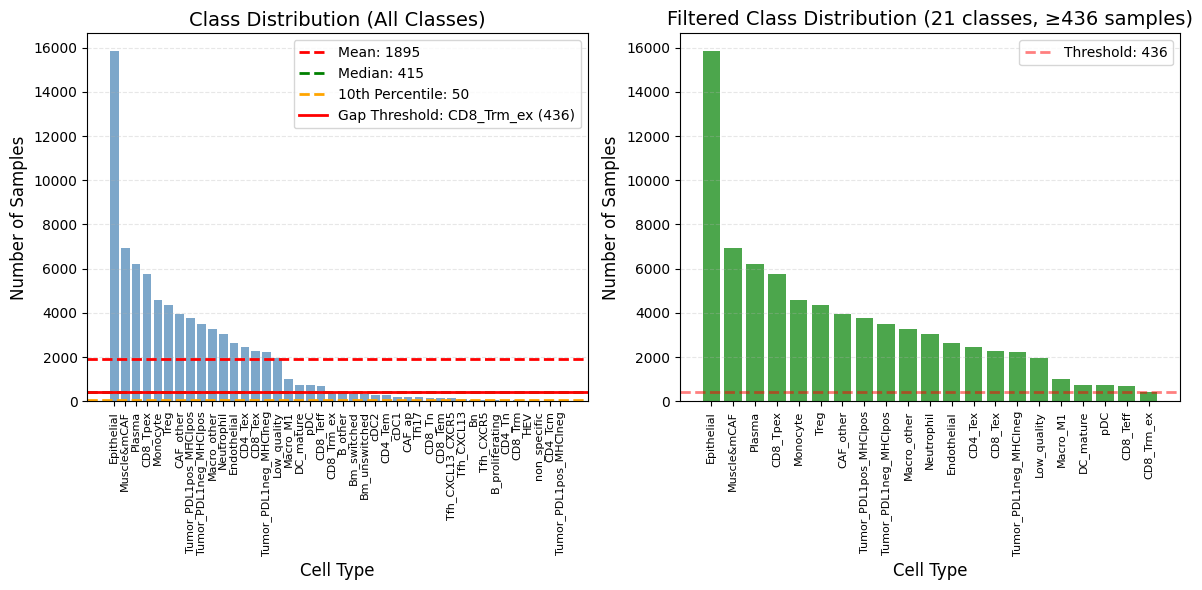


  Filtering results:
    Classes to keep: 21
    Classes to filter out: 21
    Filtered classes (< 436 samples):
      - B_other: 394 samples
      - Bm_switched: 358 samples
      - Bm_unswitched: 335 samples
      - cDC2: 287 samples
      - CD4_Tem: 272 samples
      - cDC1: 215 samples
      - CAF_ap: 215 samples
      - Th17: 196 samples
      - CD8_Tn: 161 samples
      - CD8_Tem: 141 samples
      - Tfh_CXCL13_CXCR5: 138 samples
      - Tfh_CXCL13: 106 samples
      - Bn: 68 samples
      - Tfh_CXCR5: 66 samples
      - B_proliferating: 54 samples
      - CD4_Tn: 52 samples
      - CD8_Trm: 50 samples
      - HEV: 33 samples
      - non_specific: 26 samples
      - CD4_Tcm: 5 samples
      - Tumor_PDL1pos_MHCIneg: 1 samples

  Applying filtering (removing classes with < 436 samples)...
  Before filtering: 79,605 samples, 42 classes
  After filtering: 76,432 samples, 21 classes
  Remaining class statistics:
    Max: 15,852 (Epithelial)
    Min: 436 (CD8_Trm_ex)
    Median: 3039.

In [ ]:
# Call the function to analyze and filter classes
result = analyze_and_filter_classes_by_gap(X, y, ratio_threshold=1.5, abs_diff_threshold=100)

# Extract results
X = result['X_filtered']
y = result['y_filtered']
y_encoded = result['y_encoded']
class_names = result['class_names']
threshold_cell_type = result['threshold_cell_type']
threshold_count = result['threshold_count']
min_samples_per_class = result['min_samples_per_class']

In [ ]:
# Load best model and predict on new data from matched_features_star_path
print("Loading best model and predicting on new data...")

# First, load the checkpoint to get correct model parameters
checkpoint_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/best_mlp_gpu.pt"
checkpoint = torch.load(checkpoint_path, map_location=device if 'device' in globals() else 'cpu')

# Infer input_dim and num_classes from the saved model
# input_layer.0.weight shape: [hidden_dim, input_dim]
# output_layer.weight shape: [num_classes, hidden_dim]
input_dim = checkpoint['input_layer.0.weight'].shape[1]  # Should be 384
num_classes = checkpoint['output_layer.weight'].shape[0]  # Should be 20

print(f"Model configuration (inferred from checkpoint):")
print(f"  Input dimension: {input_dim}")
print(f"  Number of classes: {num_classes}")

# Initialize model with correct parameters
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ImprovedMLPClassifier(
    input_dim=input_dim,  # Use correct input_dim from checkpoint
    num_classes=num_classes,  # Use correct num_classes from checkpoint
    hidden_dims=[1024, 512, 256],  # Same as training
    dropout=0.2  # Same as training
).to(device)

# Load the saved weights
model.load_state_dict(checkpoint)
print("✓ Model weights loaded successfully")

matched_features_star_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/matched_features_tumor1_star_float.npz'

class_names = result['class_names']

Loading best model and predicting on new data...
Model configuration (inferred from checkpoint):
  Input dimension: 384
  Number of classes: 20
✓ Model weights loaded successfully


  Loading data from matched_features_path...


  ✓ Loaded X from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/matched_features_tumor1_star_float.npz: (79605, 384)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/matched_features_tumor1_star_float.npz: (79605,), dtype: <U21
  ⚠ prediction_only=True: Labels will be used for visualization only, not for evaluation.
  ✓ Keeping labels as strings for visualization (no encoding needed)
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (79605, 384)
  No labels available - prediction mode only
X_all_scaled:  (79605, 384)
dummy_labels:  (79605,)
  Total samples: 79605
  DataLoader batch_size: 256, num_workers: 0
  Predicting on new data (no labels for evaluation)...


Predicting: 100%|██████████| 311/311 [00:42<00:00,  7.28it/s]



Prediction completed:
  Total predictions: 79605
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
  ✓ Using original labels for visualization: 79605 labels

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/matched_features_tumor1_star_float.npz: (79605, 2)
  Coordinates shape: (79605, 2)
  Predictions shape: (79605,)
  ✓ Created prediction DataFrame with 79605 cells

Plotting spatial distribution of PREDICTED cell types...
Number of valid data points: 79605
Number of cell types: 20


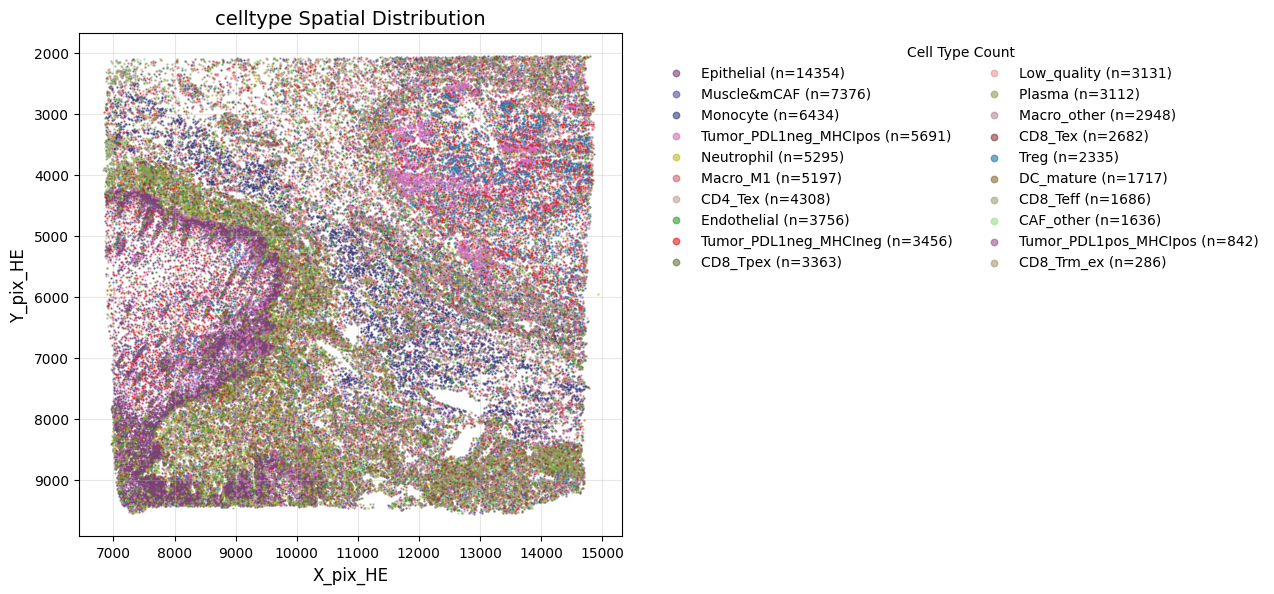


Plotting spatial distribution of TRUE cell types (for comparison)...
Number of valid data points: 79605
Number of cell types: 20


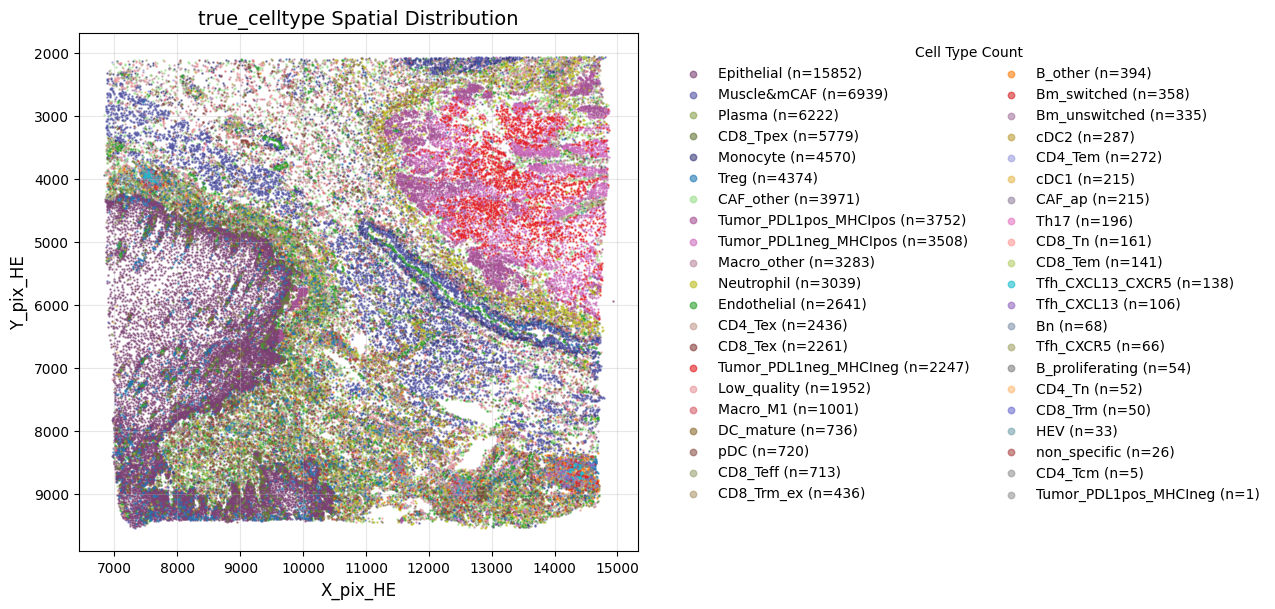

In [ ]:
# Predict on new data and plot spatial distribution
# The function will:
# 1. Load X (features) from matched_features_star_path
# 2. Use trained model to predict cell labels for ALL samples
# 3. Skip labels to avoid encoding mismatch (prediction_only=True)
# 4. Plot spatial distribution of predicted cell types
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path=matched_features_star_path,  # Input X will be loaded from here
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,  # Required: scaler from training for feature normalization
    val_loader=None,  # Don't use training val_loader - function will create its own DataLoader
    prediction_only=True,  # Skip loading labels to predict ALL samples (avoid encoding mismatch)
    # Optional: for coordinate matching if X_coords not in npz file
    X_coords_matched=X_coords_matched if 'X_coords_matched' in globals() else None,
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_stardist if 'celltype_pixel_NCRT_stardist' in globals() else None
)

  Loading data from matched_features_path...


  ✓ Loaded X from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/matched_features_tumor1_star.npz: (79584, 384)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/matched_features_tumor1_star.npz: (79584,), dtype: <U21
  ⚠ prediction_only=True: Labels will be used for visualization only, not for evaluation.
  ✓ Keeping labels as strings for visualization (no encoding needed)
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (79584, 384)
  No labels available - prediction mode only
X_all_scaled:  (79584, 384)
dummy_labels:  (79584,)
  Total samples: 79584
  DataLoader batch_size: 256, num_workers: 0
  Predicting on new data (no labels for evaluation)...


Predicting: 100%|██████████| 311/311 [00:01<00:00, 299.79it/s]



Prediction completed:
  Total predictions: 79584
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
  ✓ Using original labels for visualization: 79584 labels

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/matched_features_tumor1_star.npz: (79584, 2)
  Coordinates shape: (79584, 2)
  Predictions shape: (79584,)
  ✓ Created prediction DataFrame with 79584 cells

Plotting spatial distribution of PREDICTED cell types...


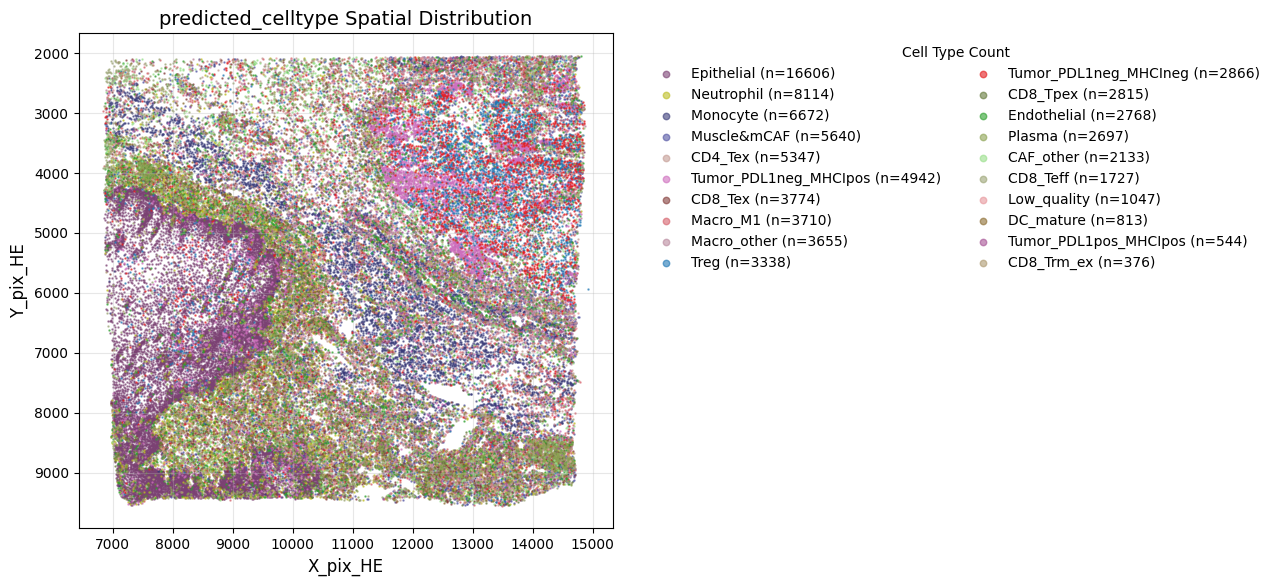


Plotting spatial distribution of TRUE cell types (for comparison)...


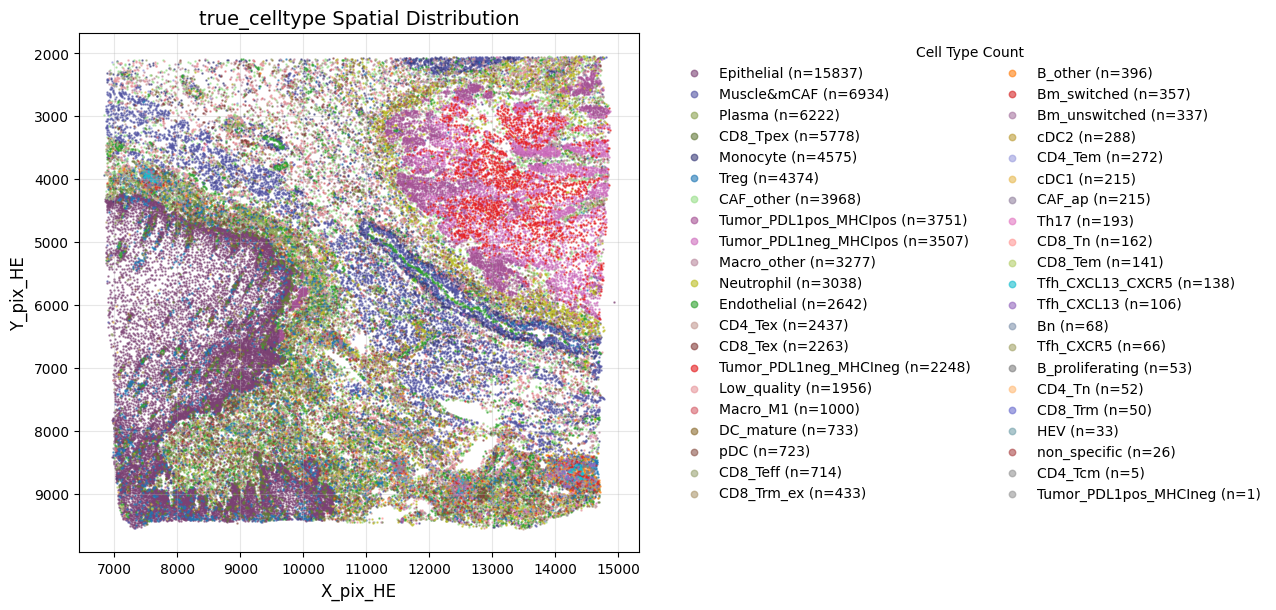

In [ ]:
# Predict on new data and plot spatial distribution
# The function will:
# 1. Load X (features) from matched_features_star_path
# 2. Use trained model to predict cell labels for ALL samples
# 3. Skip labels to avoid encoding mismatch (prediction_only=True)
# 4. Plot spatial distribution of predicted cell types
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path=matched_features_star_path,  # Input X will be loaded from here
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,  # Required: scaler from training for feature normalization
    val_loader=None,  # Don't use training val_loader - function will create its own DataLoader
    prediction_only=True,  # Skip loading labels to predict ALL samples (avoid encoding mismatch)
    # Optional: for coordinate matching if X_coords not in npz file
    X_coords_matched=X_coords_matched if 'X_coords_matched' in globals() else None,
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_stardist if 'celltype_pixel_NCRT_stardist' in globals() else None
)

## Nuclei Stardist

<!-- ## Option A: Using HIPT (recommended for quick start, no token required)
python ./code/StarDist_nuclei_segmente.py \
    --tissue NPC_allspot_p075 \
    --out_dir FineST_tutorial_data/NucleiSegments \
    --adata_path FineST_tutorial_data/SaveData/adata_imput_all_spot.h5ad \
    --img_path FineST_tutorial_data/20210809-C-AH4199551.tif \
    --prob_thresh 0.75 -->

In [ ]:
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/StarDist_nuclei_segmente.py \
#     --tissue NCRT_p075 \
#     --out_dir data/NCRT/NucleiSegments \
#     --img_path data/NCRT/NCRT_HE.qptiff \
#     --prob_thresh 0.75 \
#     --tilesize 2000

/ssd2/users/lingyu/Python/Collaborate/esccAI
2026-03-02 21:16:37.365684: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 21:16:37.367346: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 21:16:37.400217: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 21:16:37.400732: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 21:16:37.950183: W tensorflow/comp

IOStream.flush timed out


GCC version:  gcc version 13.3.0 (Ubuntu 13.3.0-6ubuntu2~24.04) 
"
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.
Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.
Using predict_instances_big: image size (70560, 47040, 3), axes=YXC, block_size=2000, min_overlap=200, context=32
effective: block_size=(2000, 2000, 3), min_overlap=(208, 208, 0), context=(32, 32, 0)
Y: context of 32 is small, recommended to use at least 94
X: context of 32 is small, recommended to use at least 94
100%|███████████████████████████████████████| 1148/1148 [07:53<00:00,  2.42it/s]
IOStream.flush timed out